In [1]:
import numpy as np
import h5py
import re
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Times New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [2]:
# -- Variable-step data (new top-level h5 layout; compatible with old segmented files) --
file_vs = "data/ns_ETD_mrGSAV_MS2_b_bursting_40_4_vs.h5"

traj_keys = ["tn", "q", "Energy", "Enstrophy", "Palinstrophy", "Mx", "CPU_time"]

def load_bursting_h5(path):
    """Load either the new top-level layout or the old segmented group layout."""
    with h5py.File(path, "r") as f:
        if "tn" in f and "Omega" in f:
            return {
                "layout": "top-level",
                "tn": f["tn"][:],
                "tn_s": f["tn_s"][:],
                "tau": f["tau"][:] if "tau" in f else np.asarray(f.attrs.get("tau")),
                "q": f["q"][:],
                "Mx": f["Mx"][:],
                "Energy": f["Energy"][:],
                "Enstrophy": f["Enstrophy"][:],
                "Palinstrophy": f["Palinstrophy"][:],
                "CPU_time": f["CPU_time"][:],
                "Omega": f["Omega"][:],
            }

        intervals = []
        for name in f.keys():
            m = re.match(r"t_([0-9.]+)_([0-9.]+)", name)
            if m:
                intervals.append((float(m.group(1)), float(m.group(2)), name))
        intervals.sort(key=lambda x: x[0])
        if not intervals:
            raise ValueError(f"No top-level datasets or t_* groups found in {path}")

        arrays = {k: [] for k in traj_keys}
        arrays["tn_s"] = []
        omega_list = []
        tau_list = []
        for i, (_, _, name) in enumerate(intervals):
            grp = f[name]
            skip = 1 if i > 0 else 0
            for k in traj_keys:
                arrays[k].append(grp[k][skip:])
            arrays["tn_s"].append(grp["tn_s"][skip:])
            omega_list.append(grp["Omega"][skip:])
            if "tau" in grp:
                tau_list.append(grp["tau"][skip:])

        out = {
            "layout": "segmented",
            "segments": [name for _, _, name in intervals],
            **{k: np.concatenate(v) for k, v in arrays.items()},
            "Omega": np.concatenate(omega_list, axis=0),
        }
        if tau_list:
            out["tau"] = np.concatenate(tau_list)
        return out

data_vs = load_bursting_h5(file_vs)
tn_vs        = data_vs["tn"]
tn_s_vs      = data_vs["tn_s"]
tau_vs       = data_vs["tau"]
q_vs         = data_vs["q"]
Mx_vs        = data_vs["Mx"]
Energy_vs    = data_vs["Energy"]
Enstrophy_vs = data_vs["Enstrophy"]
Palin_vs     = data_vs["Palinstrophy"]
CPU_vs       = data_vs["CPU_time"]
Omega_vs     = data_vs["Omega"]

print(f"VS  | layout: {data_vs['layout']}")
print(f"VS  | tn:     {tn_vs.shape}, tn_s: {tn_s_vs.shape}, Omega: {Omega_vs.shape}")
print(f"VS  | t range: [{tn_s_vs[0]:.3f}, {tn_s_vs[-1]:.3f}]")
print(f"VS  | tau range: [{tau_vs.min():.2e}, {tau_vs.max():.2e}]")


VS  | layout: segmented
VS  | tn:     (1466882,), tn_s: (10001,), Omega: (10001, 64, 64)
VS  | t range: [0.000, 9999.995]
VS  | tau range: [1.00e-05, 1.00e-02]


In [3]:
# -- Fixed-step data (new top-level h5 layout; compatible with old segmented files) --
file_fs = "data/ns_ETD_mrGSAV_MS2_b_bursting_40_4_1_0.001.h5"
# file_fs = "data/ns_ETD_mrGSAV_MS2_b_bursting_40_4_3_0.001.h5"
# file_fs = "data/ns_ETD_mrGSAV_MS2_b_bursting_40_4_3_0.0005.h5"
# file_fs = "data/ns_IMEX_bursting_40_4_3_0.0005.h5"
# file_fs = "data/ns_IMEX_bursting_40_4_3_0.001.h5"

data_fs = load_bursting_h5(file_fs)
tn_fs        = data_fs["tn"]
tn_s_fs      = data_fs["tn_s"]
q_fs         = data_fs["q"]
Mx_fs        = data_fs["Mx"]
Energy_fs    = data_fs["Energy"]
Enstrophy_fs = data_fs["Enstrophy"]
Palin_fs     = data_fs["Palinstrophy"]
CPU_fs       = data_fs["CPU_time"]
Omega_fs     = data_fs["Omega"]

print(f"FS  | layout: {data_fs['layout']}")
if data_fs["layout"] == "segmented":
    print(f"FS  | segments: {data_fs['segments']}")
print(f"FS  | tn:  {tn_fs.shape}, tn_s: {tn_s_fs.shape}, Omega: {Omega_fs.shape}")
print(f"FS  | t range: [{tn_s_fs[0]:.3f}, {tn_s_fs[-1]:.3f}]")


FS  | layout: segmented
FS  | segments: ['t_0_1000', 't_1000_2000', 't_2000_3000', 't_3000_4000', 't_4000_5000', 't_5000_6000', 't_6000_7000', 't_7000_8000', 't_8000_9000', 't_9000_10000']
FS  | tn:  (10000001,), tn_s: (10001,), Omega: (10001, 64, 64)
FS  | t range: [0.000, 10000.000]


In [12]:
# ── Representative flow scales from time-averaged kinetic energy ──────────
#
# Energy is defined in the solver as
#   E(t) = 1/2 ||u(.,t)||_{L2(Ω)}^2.
# For Ω = [0,L]^2 with L = 2π, define the representative velocity by
#   U = sqrt( 2/(L^2 T) * int_0^T E(t) dt ),
# and then set
#   Re = U L / ν,   T_e = L / U.
#
# Thus U, Re, and T_e are representative constants over the averaging window,
# not instantaneous time series.

L_domain = 2 * np.pi
nu = 1 / 40
t_flow_start = 000.0
t_flow_end = 10000.0

def integrate_over_window(time, values, t0, t1):
    time = np.asarray(time, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)

    order = np.argsort(time)
    time = time[order]
    values = values[order]

    finite = np.isfinite(time) & np.isfinite(values)
    time = time[finite]
    values = values[finite]

    # Remove duplicated segment boundaries before interpolating endpoints.
    time, unique_idx = np.unique(time, return_index=True)
    values = values[unique_idx]

    if t0 < time[0] or t1 > time[-1]:
        raise ValueError(
            f"Requested window [{t0}, {t1}] is outside the data range "
            f"[{time[0]}, {time[-1]}]."
        )

    interior = (time > t0) & (time < t1)
    t_window = np.concatenate(([t0], time[interior], [t1]))
    v_window = np.concatenate((
        [np.interp(t0, time, values)],
        values[interior],
        [np.interp(t1, time, values)],
    ))
    return np.trapezoid(v_window, t_window)

def representative_flow_scales(time, energy, t0=t_flow_start, t1=t_flow_end,
                               L=L_domain, nu=nu):
    window_length = t1 - t0
    if window_length <= 0:
        raise ValueError("The averaging window must have positive length.")

    energy_integral = integrate_over_window(time, energy, t0, t1)
    mean_energy = energy_integral / window_length
    U = np.sqrt(max(2 * mean_energy / L**2, 0.0))
    Re = U * L / nu
    Te = np.inf if U == 0 else L / U
    return {
        "energy_integral": energy_integral,
        "mean_energy": mean_energy,
        "U": U,
        "Re": Re,
        "Te": Te,
    }

flow_scales_fs = representative_flow_scales(tn_fs, Energy_fs)
flow_scales_vs = representative_flow_scales(tn_vs, Energy_vs)

def relative_difference(vs, fs):
    return (vs - fs) / fs

rows = [
    (r"U", "U"),
    (r"Re", "Re"),
    (r"T_e", "Te"),
    (r"<E>", "mean_energy"),
]

print(f"Representative flow scales from {t_flow_start:g} <= t <= {t_flow_end:g}")
print("─" * 79)
print(f"{'Quantity':<12} {'Fixed step':>16} {'Adaptive step':>16} {'Rel. diff.':>16}")
print("─" * 79)
for label, key in rows:
    fs_value = flow_scales_fs[key]
    vs_value = flow_scales_vs[key]
    rel = relative_difference(vs_value, fs_value)
    print(f"{label:<12} {fs_value:>16.6f} {vs_value:>16.6f} {100 * rel:>15.3f}%")
print("─" * 79)
print(f"int E dt   {flow_scales_fs['energy_integral']:>16.6f} "
      f"{flow_scales_vs['energy_integral']:>16.6f} "
      f"{100 * relative_difference(flow_scales_vs['energy_integral'], flow_scales_fs['energy_integral']):>15.3f}%")


Representative flow scales from 0 <= t <= 10000
───────────────────────────────────────────────────────────────────────────────
Quantity           Fixed step    Adaptive step       Rel. diff.
───────────────────────────────────────────────────────────────────────────────
U                    1.176687         1.177081           0.033%
Re                 295.733749       295.832813           0.033%
T_e                  5.339724         5.337936          -0.033%
<E>                 27.330766        27.349079           0.067%
───────────────────────────────────────────────────────────────────────────────
int E dt      273307.657809    273490.790637           0.067%


In [5]:
# ── Common plotting strides ────────────────────────────────────────────────
# Downsample dense time series only for plotting.
stride_fs = 500   # tn_fs has ~10^7 points -> keep ~20000
stride_vs = 50    # tn_vs has ~1.5×10^6 points -> keep ~30000


In [6]:
# ── 时间加权 KDE（稳态，t > 1000）───────────────────────────────────────────
#
# gaussian_kde 的 weights 参数直接接受非均匀权重：
#   固定步长：均匀权重（省略即可）
#   变步长  ：weights = tau_vs，每个采样点按实际步长加权
#
# 数据量大时对 FS 降采样，VS 保留全部（权重结构不能破坏）

from scipy.stats import gaussian_kde

t_cutoff = 1000
tau_fs   = 0.01

# ── 稳态数据 ──────────────────────────────────────────────────────────────
i0_fs   = int(t_cutoff / tau_fs)
stride  = 20                            # FS 降采样：1000万→50万
E_fs_ss = Enstrophy_fs[i0_fs::stride]

mask_vs = tn_vs >= t_cutoff
E_vs_ss = Enstrophy_vs[mask_vs]
w_vs    = tau_vs[mask_vs]

print(f"FS KDE points : {len(E_fs_ss):,}")
print(f"VS KDE points : {len(E_vs_ss):,}  (weighted by tau_vs)")

# ── KDE ──────────────────────────────────────────────────────────────────
kde_fs = gaussian_kde(E_fs_ss)                    # 等权重，默认 Scott 带宽
kde_vs = gaussian_kde(E_vs_ss, weights=w_vs)      # 时间加权

Z_grid = np.linspace(50, 1500, 2000)
pdf_fs = kde_fs(Z_grid)
pdf_vs = kde_vs(Z_grid)


FS KDE points : 495,001
VS KDE points : 1,260,524  (weighted by tau_vs)


In [7]:
# ── 时间加权统计矩（稳态，t > 1000）─────────────────────────────────────────
#
# 固定步长：等权重，np.average / np.var 直接计算
# 变步长  ：weights = tau_vs，np.average(x, weights=w) = Σ(x_i·w_i)/Σw_i

t_cutoff = 1000
tau_fs   = 0.01

i0_fs   = int(t_cutoff / tau_fs)
E_fs_ss = Enstrophy_fs[i0_fs:]        # 全量，不降采样（矩计算无需降采样）

mask_vs = tn_vs >= t_cutoff
E_vs_ss = Enstrophy_vs[mask_vs]
w_vs    = tau_vs[mask_vs]

def weighted_moments(x, w=None):
    """返回 (均值, 一阶原点矩, 二阶原点矩, 方差, 标准差)"""
    mu1  = np.average(x,      weights=w)          # 一阶原点矩 = 均值
    mu2  = np.average(x**2,   weights=w)          # 二阶原点矩
    var  = np.average((x - mu1)**2, weights=w)    # 方差 = μ₂ - μ₁²
    std  = np.sqrt(var)
    return mu1, mu2, var, std

mu1_fs, mu2_fs, var_fs, std_fs = weighted_moments(E_fs_ss)
mu1_vs, mu2_vs, var_vs, std_vs = weighted_moments(E_vs_ss, w=w_vs)

header = f"{'统计量':<16} {'固定步长 (FS)':>18} {'变步长 (VS)':>18}"
sep    = "─" * len(header)
rows = [
    ("均值  E[Z]",       mu1_fs,  mu1_vs),
    ("一阶矩 E[Z]",      mu1_fs,  mu1_vs),
    ("二阶矩 E[Z²]",     mu2_fs,  mu2_vs),
    ("方差  Var[Z]",     var_fs,  var_vs),
    ("标准差 Std[Z]",    std_fs,  std_vs),
]

print(sep)
print(header)
print(sep)
for label, v_fs, v_vs in rows:
    print(f"{label:<16} {v_fs:>18.4f} {v_vs:>18.4f}")
print(sep)
print(f"\n相对差 (VS−FS)/FS:")
for label, v_fs, v_vs in rows:
    rel = (v_vs - v_fs) / v_fs * 100
    print(f"  {label:<14}  {rel:+.3f}%")


──────────────────────────────────────────────────────
统计量                       固定步长 (FS)           变步长 (VS)
──────────────────────────────────────────────────────
均值  E[Z]                    92.0511            91.4004
一阶矩 E[Z]                    92.0511            91.4004
二阶矩 E[Z²]                 9365.3746          9232.4946
方差  Var[Z]                 891.9611           878.4592
标准差 Std[Z]                  29.8657            29.6388
──────────────────────────────────────────────────────

相对差 (VS−FS)/FS:
  均值  E[Z]        -0.707%
  一阶矩 E[Z]        -0.707%
  二阶矩 E[Z²]       -1.419%
  方差  Var[Z]      -1.514%
  标准差 Std[Z]      -0.760%


In [8]:
# ── Total Variation Distance & 相对 L1 范数（稳态 KDE）───────────────────────
#
# 基于前一个 cell 得到的 kde_fs, kde_vs，在指定区间上数值积分
#
# TVD([a,b])      = (1/2) ∫_a^b |p_fs(x) - p_vs(x)| dx
#
# 相对 L1([a,b])  = ∫_a^b |p_fs(x) - p_vs(x)| dx
#                   ─────────────────────────────────
#                   (1/2)[∫_a^b p_fs(x)dx + ∫_a^b p_vs(x)dx]
#
# 分母取两者概率质量的均值，使指标在 [0,2] 上，与区间选取无关的相对尺度

N_GRID = 5000     # 积分网格密度

def interval_metrics(kde_p, kde_q, a, b, n=N_GRID):
    """
    返回区间 [a,b] 上的:
      mass_p, mass_q  : 各自的概率质量
      tvd             : Total Variation Distance
      rel_l1          : 相对 L1 范数
    """
    z   = np.linspace(a, b, n)
    p   = kde_p(z)
    q   = kde_q(z)
    dz  = z[1] - z[0]

    mass_p  = np.trapezoid(p, dx=dz)
    mass_q  = np.trapezoid(q, dx=dz)
    l1      = np.trapezoid(np.abs(p - q), dx=dz)

    tvd     = 0.5 * l1
    rel_l1  = l1 / (0.5 * (mass_p + mass_q)) if (mass_p + mass_q) > 0 else np.nan

    return mass_p, mass_q, tvd, rel_l1

# 全范围用 [0, 2000]，覆盖 KDE 的有效支撑
intervals = [
    ("(0,   120)",    0,     120),
    ("(120, 400)",  120,     400),
    ("(-∞,  +∞)",     0,     500),
]

header = (f"{'区间':<14} {'P_FS':>8} {'P_VS':>8} "
          f"{'TVD':>10} {'相对L1':>10}")
sep = "─" * len(header)
print(sep)
print(header)
print(sep)
for label, a, b in intervals:
    mass_p, mass_q, tvd, rel_l1 = interval_metrics(kde_fs, kde_vs, a, b)
    print(f"{label:<14} {mass_p:>8.4f} {mass_q:>8.4f} "
          f"{tvd:>10.6f} {rel_l1:>10.6f}")
print(sep)
print()
print("说明:")
print("  P_FS / P_VS  : 各分布在该区间的概率质量 ∫p dx")
print("  TVD          : Total Variation Distance = (1/2)∫|p-q|dx")
print("  相对L1        : ∫|p-q|dx / [(P_FS+P_VS)/2]，范围 [0,2]")

──────────────────────────────────────────────────────
区间                 P_FS     P_VS        TVD       相对L1
──────────────────────────────────────────────────────
(0,   120)       0.9103   0.9172   0.012379   0.027095
(120, 400)       0.0897   0.0828   0.006306   0.146295
(-∞,  +∞)        1.0000   1.0000   0.018686   0.037372
──────────────────────────────────────────────────────

说明:
  P_FS / P_VS  : 各分布在该区间的概率质量 ∫p dx
  TVD          : Total Variation Distance = (1/2)∫|p-q|dx
  相对L1        : ∫|p-q|dx / [(P_FS+P_VS)/2]，范围 [0,2]


Ada. slope : 0.0005 h/t   (intercept 0.163)
Fix. slope : 0.0033 h/t
Speedup    : 6.46×


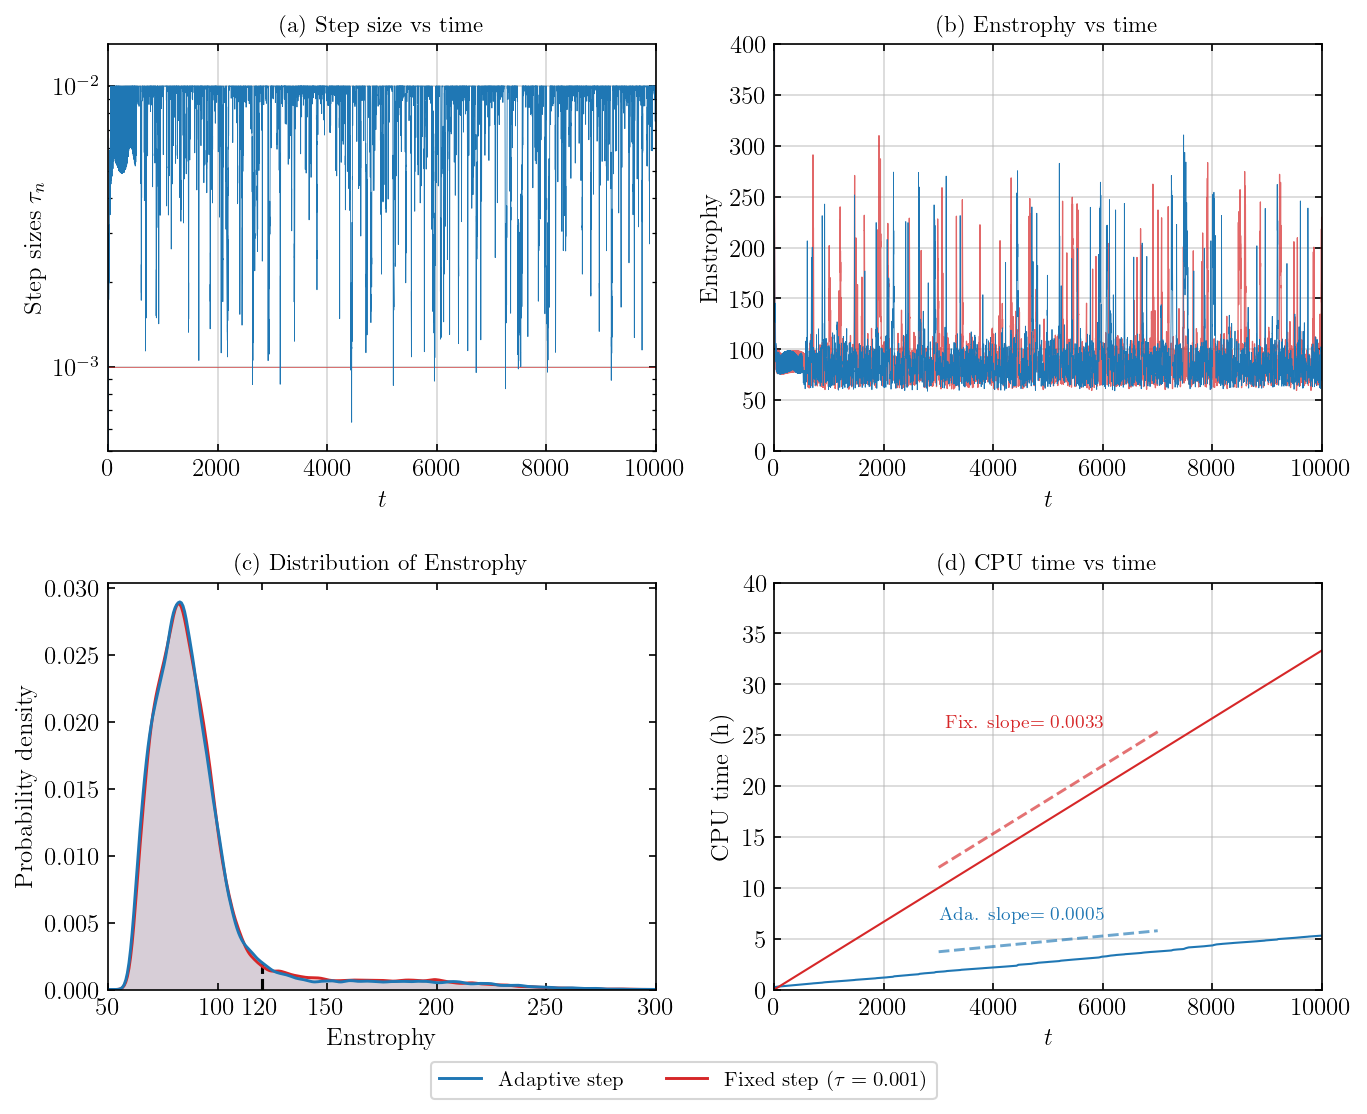

In [9]:
# ── Variable-step 自适应步长诊断：2×2 子图 ──────────────────────────────────
#
# (a) 步长 τ 随时间变化          (b) Enstrophy 随时间变化
# (c) Enstrophy distribution comparison   (d) 物理时间 t 与计算步数的关系

stride = 50   # 1.5×10^6 → ~30000 点，足够线图

t   = tn_vs[::stride]
tau = tau_vs[::stride]
E   = Enstrophy_vs[::stride]
n   = np.arange(len(tn_vs))[::stride]   # 累计步数

fixed_color = "C3"
adaptive_color = "C0"
fixed_label = r"Fixed step ($\tau=0.001$)"
adaptive_label = r"Adaptive step"

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True, dpi=150)
fig.set_constrained_layout_pads(h_pad=0.05, hspace=0.08)

# ── (a) 步长随时间变化 ──────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hlines(1e-3, 0, 10000, color=fixed_color, linewidth=0.4, alpha = 0.7, rasterized=True)
ax.plot(t, tau, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_yscale("log")
ax.set_xlim(0, 10000)
ax.set_ylim(bottom = 5*10**-4)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Step sizes $\tau_n$")
ax.set_title(r"(a) Step size vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha = 0.5)

# ── (b) Enstrophy 随时间变化 ────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(tn_fs[::stride_fs], Enstrophy_fs[::stride_fs], color=fixed_color, alpha = 0.7, linewidth=0.6)
ax.plot(t, E, color=adaptive_color, linewidth=0.4, rasterized=True)
ax.set_xlim(0, 10000)
ax.set_ylim(0, 400)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Enstrophy")
ax.set_title(r"(b) Enstrophy vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha = 0.5)

# ── (c) Enstrophy distribution comparison ────────────────────────────────
ax = axes[1, 0]
ax.vlines(120, 0, 0.002, color = "k", linestyles="--")
for pdf, color in [
        (pdf_fs, fixed_color),
        (pdf_vs, adaptive_color)
        ]:
    ax.fill_between(Z_grid, pdf, color=color, alpha=0.15, linewidth=0)
    ax.plot(Z_grid, pdf, color=color, linewidth=1.4)

ax.set_xticks([50,100,120,150,200,250,300])
ax.set_xlim(50, 300)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Enstrophy")
ax.set_ylabel(r"Probability density")
ax.set_title(r"(c) Distribution of Enstrophy", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)

# ── (d) 物理时间 t 与累计步数的关系 ─────────────────────────────────────────
ax = axes[1, 1]
ax.plot(t, n*0.013/3600, color=adaptive_color, linewidth=1, rasterized=True, linestyle="-")
# 对比：若用固定步长 τ=0.001，总步数 = t/0.001（虚线参考）
t_ref = np.linspace(0, 10000, 500)
n_ref = t_ref / 0.001
ax.plot(t_ref, n_ref*0.012/3600, color=fixed_color, linewidth=1.0, linestyle="-")

# ── 线性拟合斜率（np.polyfit 一阶多项式）────────────────────────────────────
k_ada, b_ada = np.polyfit(t, n * 0.013 / 3600, 1)
k_fix = (1 / 0.001) * 0.012 / 3600          # 解析斜率，完全线性

# 辅助拟合线（虚线，覆盖全 t 范围）
t_line = np.array([3000, 7000.])
ax.plot(t_line, k_ada * t_line + b_ada + 2, color=adaptive_color, linewidth=1.4, linestyle="--", alpha=0.65)
ax.plot(t_line, k_fix * t_line + 2, color=fixed_color, linewidth=1.4, linestyle="--", alpha=0.65)

# 斜率数值标注
ax.text(6000, k_ada * 9700 + b_ada + 3,
        rf"Ada. slope$={k_ada:.4f}$", ha="right", va="top", fontsize=9, color=adaptive_color)
ax.text(6000, k_fix * 9700 - 7,
        rf"Fix. slope$={k_fix:.4f}$",
        ha="right", va="bottom", fontsize=9, color=fixed_color)

print(f"Ada. slope : {k_ada:.4f} h/t   (intercept {b_ada:.3f})")
print(f"Fix. slope : {k_fix:.4f} h/t")
print(f"Speedup    : {k_fix/k_ada:.2f}×")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"CPU time (h)")
ax.set_xlim(0, 10000)
ax.set_ylim(0, 40)
ax.set_title(r"(d) CPU time vs time", loc="center", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(alpha = 0.5)

legend_handles = [
    plt.Line2D([0], [0], color=adaptive_color, linewidth=1.4, label=adaptive_label),
    plt.Line2D([0], [0], color=fixed_color, linewidth=1.4, label=fixed_label),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.savefig("fig/vs_diagnostics.pdf", dpi=150, bbox_inches="tight")
plt.show()


,k,FS threshold,FS burst count,VS threshold,VS burst count,count error (%)
0,1.0,121.9169,95,121.0392,102,7.37
1,1.5,136.8497,77,135.8586,68,11.69
2,2.0,151.7826,68,150.6780,62,8.82
3,3.0,181.6483,72,180.3169,62,13.89
4,4.0,211.5140,58,209.9557,62,6.90
5,5.0,241.3797,26,239.5945,31,19.23


FS threshold = 151.7826, count = 68
  max duration  = 39.6870 on [8479.1990, 8518.8860]
  mean duration = 7.4951
  mean interval = 131.2048
VS threshold = 150.6780, count = 62
  max duration  = 71.8927 on [7468.9542, 7540.8469]
  mean duration = 7.5915
  mean interval = 135.7075


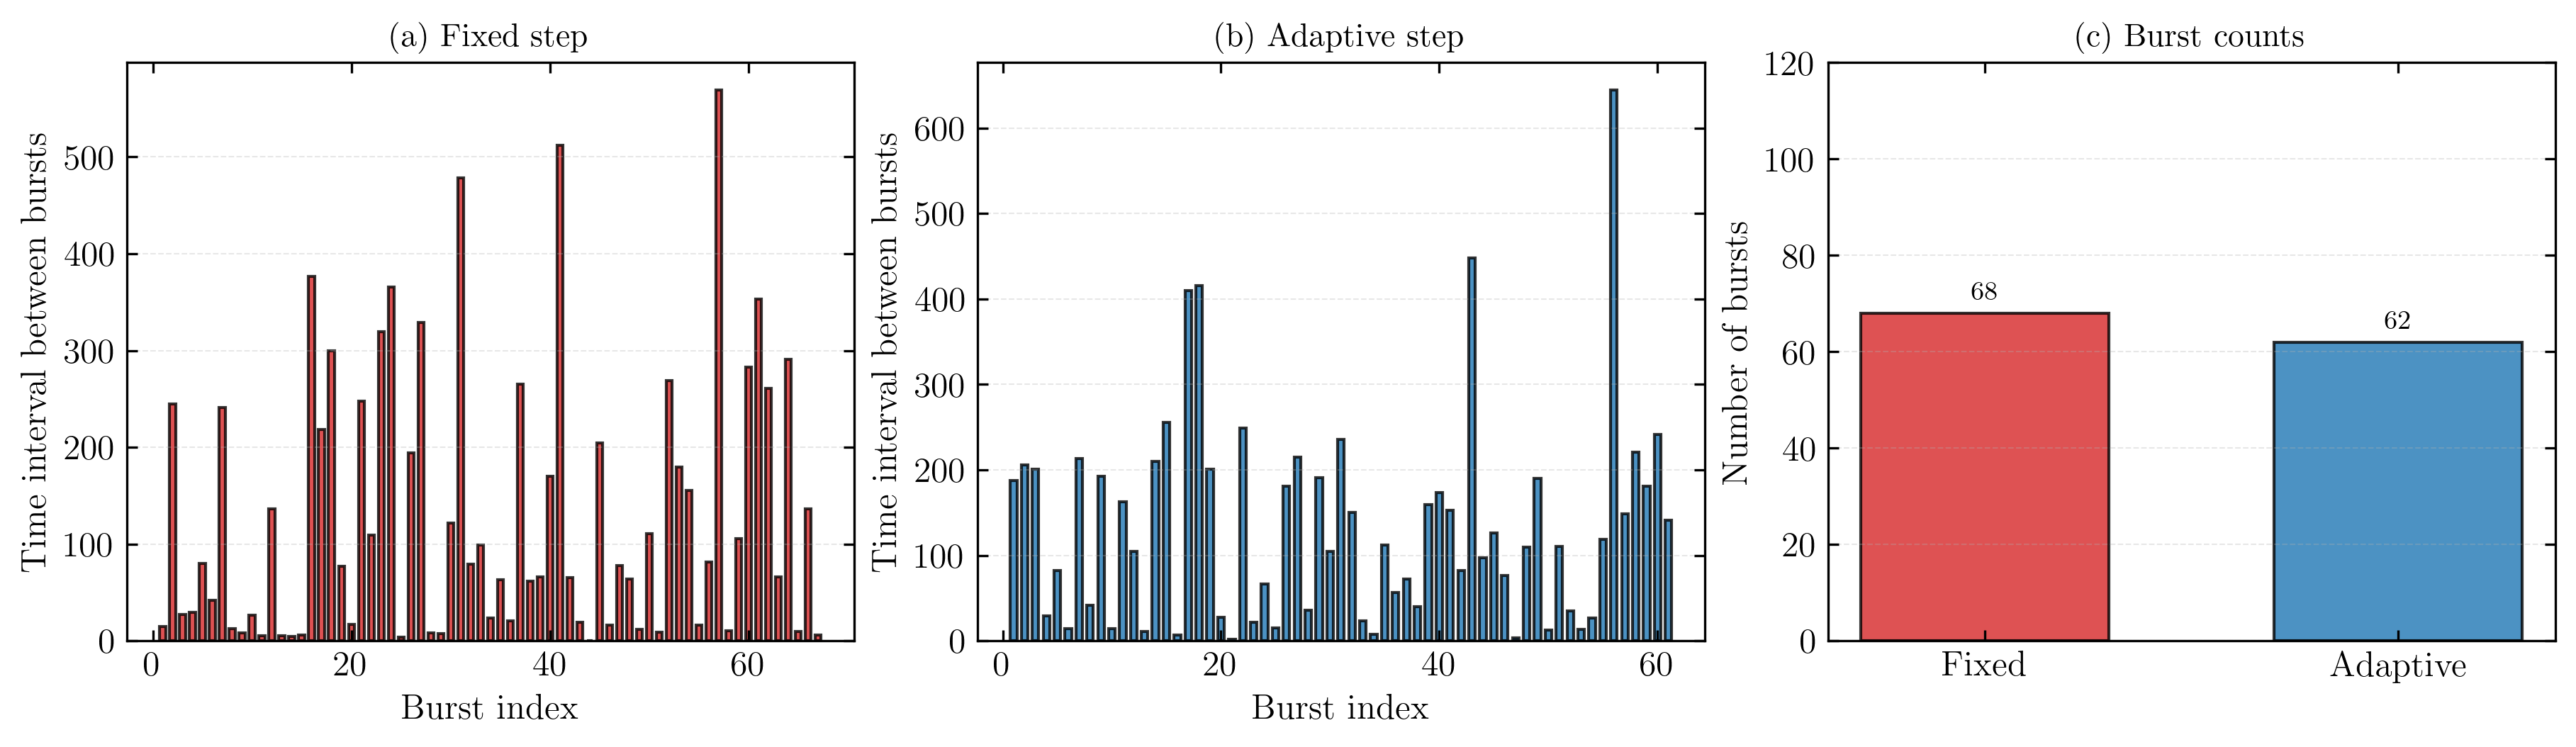

In [10]:
# ── Bursting 事件统计：连续超过阈值的一段时间算作一个 burst ────────────────
#
# 这里采用新的定义：
# 1. 先找出 Enstrophy > mean + 3 std 的采样点；
# 2. 将连续超过阈值的时间区间视为同一次 burst；
# 3. 统计每个 burst 的起止时间、持续时间，以及相邻 burst 起始时刻间隔。

t_cutoff_burst = 1200

def detect_burst_segments(t, E, threshold, t_cutoff=0):
    mask = t >= t_cutoff
    t_ss = t[mask]
    E_ss = E[mask]

    above = E_ss > threshold
    if not np.any(above):
        empty = np.asarray([])
        return {
            "threshold": threshold,
            "start_indices": empty.astype(int),
            "end_indices": empty.astype(int),
            "start_times": empty,
            "end_times": empty,
            "durations": empty,
            "time_intervals": empty,
            "count": 0,
            "max_duration": np.nan,
            "mean_duration": np.nan,
        }

    padded = np.r_[False, above, False]
    transitions = np.diff(padded.astype(np.int8))
    start_indices = np.flatnonzero(transitions == 1)
    end_indices = np.flatnonzero(transitions == -1) - 1

    start_times = t_ss[start_indices]
    end_times = t_ss[end_indices]
    durations = end_times - start_times
    time_intervals = np.diff(start_times)

    return {
        "threshold": threshold,
        "start_indices": start_indices,
        "end_indices": end_indices,
        "start_times": start_times,
        "end_times": end_times,
        "durations": durations,
        "time_intervals": time_intervals,
        "count": len(durations),
        "max_duration": np.max(durations),
        "mean_duration": np.mean(durations),
    }

burst_fs = detect_burst_segments(
    tn_fs, Enstrophy_fs, threshold=mu1_fs + 2*std_fs,
    t_cutoff=t_cutoff_burst
)
burst_vs = detect_burst_segments(
    tn_vs, Enstrophy_vs, threshold=mu1_vs + 2*std_vs,
    t_cutoff=t_cutoff_burst
)

# Burst-count sensitivity with respect to the threshold mean + k std.
k_values_burst = np.array([1.0, 1.5, 2.0, 3.0, 4.0, 5.0])
burst_count_rows = []
for k in k_values_burst:
    threshold_fs = mu1_fs + k * std_fs
    threshold_vs = mu1_vs + k * std_vs
    burst_k_fs = detect_burst_segments(
        tn_fs, Enstrophy_fs, threshold=threshold_fs,
        t_cutoff=t_cutoff_burst
    )
    burst_k_vs = detect_burst_segments(
        tn_vs, Enstrophy_vs, threshold=threshold_vs,
        t_cutoff=t_cutoff_burst
    )
    fs_count = burst_k_fs["count"]
    vs_count = burst_k_vs["count"]
    count_error_pct = 100 * abs(fs_count - vs_count) / fs_count if fs_count > 0 else np.nan
    burst_count_rows.append({
        "k": k,
        "FS threshold": threshold_fs,
        "FS burst count": fs_count,
        "VS threshold": threshold_vs,
        "VS burst count": vs_count,
        "count error (%)": count_error_pct,
    })

try:
    import pandas as pd
    burst_count_table = pd.DataFrame(burst_count_rows)
    display(burst_count_table.style.format({
        "k": "{:.1f}",
        "FS threshold": "{:.4f}",
        "VS threshold": "{:.4f}",
        "count error (%)": "{:.2f}",
    }))
except ImportError:
    burst_count_table = burst_count_rows
    print(f"{'k':>4} {'FS threshold':>14} {'FS bursts':>10} {'VS threshold':>14} "
          f"{'VS bursts':>10} {'error (%)':>10}")
    print("-" * 74)
    for row in burst_count_rows:
        print(f"{row['k']:>4.1f} {row['FS threshold']:>14.4f} {row['FS burst count']:>10d} "
              f"{row['VS threshold']:>14.4f} {row['VS burst count']:>10d} "
              f"{row['count error (%)']:>10.2f}")

def print_burst_duration_summary(label, burst):
    if burst["count"] == 0:
        print(f"{label} threshold = {burst['threshold']:.4f}, count = 0")
        return

    i_max = int(np.argmax(burst["durations"]))
    print(f"{label} threshold = {burst['threshold']:.4f}, count = {burst['count']}")
    print(f"  max duration  = {burst['max_duration']:.4f} "
          f"on [{burst['start_times'][i_max]:.4f}, {burst['end_times'][i_max]:.4f}]")
    print(f"  mean duration = {burst['mean_duration']:.4f}")
    print(f"  mean interval = {np.mean(burst['time_intervals']):.4f}")

print_burst_duration_summary("FS", burst_fs)
print_burst_duration_summary("VS", burst_vs)

fixed_color = "C3"
adaptive_color = "C0"

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True, dpi=300)

# ── (a) Fixed-step bursting 间隔柱形图：相邻 burst 起始时刻之差─────────────
ax = axes[0]
x_pos = np.arange(1, len(burst_fs['time_intervals']) + 1)
bars = ax.bar(x_pos, burst_fs['time_intervals'], color=fixed_color,
              edgecolor='black', alpha=0.8, width=0.6)
ax.set_xlabel(r"Burst index")
ax.set_ylabel(r"Time interval between bursts")
ax.set_title(r"(a) Fixed step", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

# ── (b) Adaptive-step bursting 间隔柱形图：相邻 burst 起始时刻之差 ──────────
ax = axes[1]
x_pos = np.arange(1, len(burst_vs['time_intervals']) + 1)
bars = ax.bar(x_pos, burst_vs['time_intervals'], color=adaptive_color,
              edgecolor='black', alpha=0.8, width=0.6)
ax.set_xlabel(r"Burst index")
ax.set_ylabel(r"Time interval between bursts")
ax.set_title(r"(b) Adaptive step", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

# ── (c) Bursting 次数比较 ────────────────────────────────────────────────
ax = axes[2]
labels = [r"Fixed", r"Adaptive"]
counts = [burst_fs['count'], burst_vs['count']]
colors = [fixed_color, adaptive_color]
x = np.arange(len(labels))
bars = ax.bar(x, counts, color=colors, edgecolor='black', alpha=0.8, width=0.6)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0,120)
ax.set_xticks(x, labels)
ax.set_ylabel(r"Number of bursts")
ax.set_title(r"(c) Burst counts", fontsize=11)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(axis="y", alpha=0.3, linestyle="dashed", linewidth=0.5)

from pathlib import Path
Path("figure").mkdir(exist_ok=True)
plt.savefig("fig/bursting_event_comparison.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()


To examine the long-time behavior in a more unstable regime, we set $m=4$, $\nu=1/40$, and $\bar{C}=1000$, and take the initial streamfunction as a perturbation of the corresponding steady state in the form \ref{initial}. The final time is $T=10000$, and the spatial discretization uses 256 Fourier modes in each spatial direction. We compare a fixed-step ETD-mr-SAV-MS2o computation with $\tau=10^{-3}$ and an adaptive ETD-mr-SAV-MS12 computation with the controller parameters specified in \ref{adaptive_set}. In the following comparisons, the interval $1000<t<10000$ is regarded as the statistically steady regime. Unless stated otherwise, all reported moments, distributional quantities, and time averages are computed on this interval; for the adaptive computation, time averages are weighted by the nonuniform step lengths.

Figure~\ref{fig:adaptive_step_k} summarizes the long-time diagnostics. Panel (a) shows the adaptive time steps together with the fixed-step reference. The controller decreases $\tau_n$ during high-enstrophy episodes and increases it during relatively quiescent intervals. This relation is quantified by the Pearson correlation coefficient between $\tau_n$ and the enstrophy along the adaptive trajectory,
\[
PCC(x,y)=\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2\sum_i (y_i-\bar{y})^2}},
\]
where $\bar{x}$ and $\bar{y}$ denote the corresponding sample means. The computed value is $PCC=-0.8370$, which indicates a strong negative correlation between the step size and the flow activity. Panel (b) compares the enstrophy histories produced by the two computations. Although the two trajectories separate over long times, as expected in this sensitive regime, both remain uniformly bounded on $[0,T]$. Panel (c) compares the steady-state probability density functions of the enstrophy, and panel (d) reports the cumulative CPU time as a function of physical time. The adaptive computation reaches $T=10000$ using approximately $1.47\times10^6$ time steps and $28.5$ hours of wall-clock time, whereas the fixed-step computation requires $10^7$ time steps and approximately $194.4$ hours. Thus, the adaptive strategy reduces the computational cost by a factor of about $6.8$ while preserving the long-time statistical behavior described below.

\begin{figure}[htbp]
    \centering
    \includegraphics[width=\linewidth]{figure/vs_diagnostics.pdf}
    \caption{Long-time diagnostics in the bursting regime with $\nu=1/40$ and $m=4$. (a) Adaptive step sizes $\tau_n$ as a function of time, with the fixed step $\tau=10^{-3}$ shown for reference. (b) Enstrophy histories from the fixed-step and adaptive-step computations. (c) Probability density functions of enstrophy estimated on the statistically steady interval. (d) CPU time as a function of physical time for the fixed-step and adaptive-step computations.}
    \label{fig:adaptive_step_k}
\end{figure}

We first compare the steady-state moments of the enstrophy distribution. As shown in Table~\ref{tab:moment_comparison}, the adaptive computation reproduces the fixed-step mean, second raw moment, variance, and standard deviation with relative differences below $2\%$. These values indicate that the adaptive step selection does not introduce a detectable bias in either the mean enstrophy level or the size of its fluctuations.

\begin{table}[htbp]
\centering
\caption{Comparison of steady-state enstrophy moments for the fixed-step and adaptive-step computations with $\nu=1/40$ and $m=4$. The statistics are computed on $1000<t<10000$.}
\label{tab:moment_comparison}
\begin{tabular}{@{}lccc@{}}
\toprule
Statistic & Fixed step & Adaptive step & Relative difference \\
\midrule
Mean $\mathbb{E}[\mathcal{E}]$ & $92.0511$ & $91.4004$ & $-0.707\%$ \\
First moment $\mathbb{E}[\mathcal{E}]$ & $92.0511$ & $91.4004$ & $-0.707\%$ \\
Second moment $\mathbb{E}[\mathcal{E}^2]$ & $9365.3746$ & $9232.4946$ & $-1.419\%$ \\
Variance $\mathrm{Var}(\mathcal{E})$ & $891.9611$ & $878.4592$ & $-1.514\%$ \\
Standard deviation & $29.8657$ & $29.6388$ & $-0.760\%$ \\
\bottomrule
\end{tabular}
\end{table}

We next compute representative flow scales from the time-averaged kinetic energy over the full interval $0<t<T$. Since the kinetic energy is defined as $E(t)=\frac12\|\boldsymbol{u}(\cdot,t)\|_{L^2(\Omega)}^2$, and since the domain is the square of side length $L=2\pi$, we define
\[
U = \sqrt{\frac{2}{L^2T}\int_0^T E(t)\,dt},\qquad Re=\frac{UL}{\nu},\qquad T_e=\frac{L}{U}.
\]
Here $U$ is a representative velocity scale, $Re$ is the corresponding Reynolds number, and $T_e$ is the eddy turnover time associated with this velocity scale. Table~\ref{tab:flow_scales_comparison} shows that the two computations give nearly identical representative values: the relative differences are about $0.03\%$ for $U$, $Re$, and $T_e$.

\begin{table}[htbp]
\centering
\caption{Representative flow scales computed from the time-averaged kinetic energy over $0<t<T$ with $T=10000$. The relative difference is computed as $(\mathrm{VS}-\mathrm{FS})/\mathrm{FS}$.}
\label{tab:flow_scales_comparison}
\begin{tabular}{@{}lccc@{}}
\toprule
Quantity & Fixed step & Adaptive step & Relative difference \\
\midrule
Representative velocity $U$ & $1.176687$ & $1.177081$ & $0.033\%$ \\
Reynolds number $Re$ & $295.733749$ & $295.832813$ & $0.033\%$ \\
Eddy turnover time $T_e$ & $5.339724$ & $5.337936$ & $-0.033\%$ \\
\bottomrule
\end{tabular}
\end{table}

The distributional discrepancy is also small. Table~\ref{tab:tv_comparison} reports the probability masses, total variation distances, and relative $L^1$ errors for the low-enstrophy range $\mathcal{E}<120$, the bursting-tail range $\mathcal{E}\geq120$, and the full resolved range. The total variation distance is $0.012379$ in the low-enstrophy range, $0.006306$ in the bursting-tail range, and $0.018686$ over the full range. These results show that the adaptive computation approximates the steady-state enstrophy distribution of the fixed-step reference with small distributional error.

\begin{table}[htbp]
\centering
\caption{Total variation distance between the steady-state enstrophy distributions obtained by ETD-mr-SAV-MS2o and ETD-mr-SAV-MS12 for $\nu=1/40$ and $m=4$. The KDEs are computed on $1000<t<10000$.}
\label{tab:tv_comparison}
\begin{tabular}{@{}lcccc@{}}
\toprule
Enstrophy range & $P_{\mathrm{FS}}$ & $P_{\mathrm{VS}}$ & Total variation distance & Relative $L^1$ error \\
\midrule
$\mathcal{E}<120$ & $0.9103$ & $0.9172$ & $0.012379$ & $2.71\%$ \\
$\mathcal{E}\geq120$ & $0.0897$ & $0.0828$ & $0.006306$ & $12.63\%$ \\
Full range & $1.0000$ & $1.0000$ & $0.018686$ & $3.74\%$ \\
\bottomrule
\end{tabular}
\end{table}

Finally, we count bursting events within the statistically steady regime. To avoid sensitivity to the beginning of the averaging window, the event count is taken for $t\geq1200$. A burst is defined as one connected time interval over which the enstrophy exceeds $\mathbb{E}[\mathcal{E}]+k\operatorname{Std}(\mathcal{E})$, where the mean and standard deviation are those reported in Table~\ref{tab:moment_comparison}. Table~\ref{tab:burst_count_thresholds} gives the counts for $k=1,1.5,2,3,4,5$, together with the corresponding thresholds and the absolute count error relative to the fixed-step computation. The absolute count error ranges from $6.90\%$ to $19.23\%$ over these thresholds. For the representative choice $k=2$, the fixed-step computation gives 68 bursts, corresponding to $68/(10000-1200)=7.73\times10^{-3}$ events per unit time, while the adaptive computation gives 62 bursts, corresponding to $62/(10000-1200)=7.05\times10^{-3}$ events per unit time. The mean intervals between burst onsets are $131.2048$ and $135.7075$, respectively.

\begin{table}[htbp]
\centering
\caption{Burst counts for thresholds $\mathbb{E}[\mathcal{E}]+k\operatorname{Std}(\mathcal{E})$ after $t\geq1200$. The absolute count error is computed as $|\#\mathrm{FS}-\#\mathrm{VS}|/\#\mathrm{FS}$.}
\label{tab:burst_count_thresholds}
\begin{tabular}{@{}cccccc@{}}
\toprule
$k$ & FS threshold & FS burst count & VS threshold & VS burst count & Absolute count error \\
\midrule
$1.0$ & $121.9169$ & $95$ & $121.0392$ & $102$ & $7.37\%$ \\
$1.5$ & $136.8497$ & $77$ & $135.8586$ & $68$ & $11.69\%$ \\
$2.0$ & $151.7826$ & $68$ & $150.6780$ & $62$ & $8.82\%$ \\
$3.0$ & $181.6483$ & $72$ & $180.3169$ & $62$ & $13.89\%$ \\
$4.0$ & $211.5140$ & $58$ & $209.9557$ & $62$ & $6.90\%$ \\
$5.0$ & $241.3797$ & $26$ & $239.5945$ & $31$ & $19.23\%$ \\
\bottomrule
\end{tabular}
\end{table}

Taken together, these comparisons indicate that ETD-mr-SAV-MS12 maintains long-time stability, reproduces the steady-state enstrophy statistics and representative flow scales of the fixed-step reference, and captures the frequency of intermittent bursting events while reducing the computational cost substantially.
